In [8]:
from torchvision import datasets
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
from torch.utils.data import Subset
import shutil
from pathlib import Path
from tqdm import tqdm

In [9]:
from scipy.stats import entropy as scipy_entropy
def kl_from_uniform(labels: np.ndarray) -> float:
    valid = labels[labels >= 0]
    k = int(labels.max()) + 1
    counts = np.bincount(valid, minlength=k).astype(float)
    counts = counts[counts > 0]   # ignore empty bins
    p = counts / counts.sum()
    k_eff = len(counts)
    uniform = np.ones(k_eff) / k_eff
    return float(scipy_entropy(p, uniform))

def vis_counts(counts,ax=None):
    if ax is None:
        fig,ax = plt.subplots(1,1)
    ax.bar(x=np.arange(len(counts)), height=counts)

In [ ]:
ds_big = datasets.ImageFolder(r"D:\places365\train")

KeyboardInterrupt: 

In [ ]:
chosen_classes = ['airport_terminal','beach','bedroom','canyon','classroom','forest_path',
                    'kitchen','mountain','office','restaurant']

In [ ]:
chosen_classes_idx = np.where(np.isin(ds_big.classes,chosen_classes))[0]
idx_chosen = np.where(np.isin(ds_big.targets,chosen_classes_idx))[0]
sub_big = [ds_big[i] for i in idx_chosen]
ds_big_chose_class_idx = [ds_big.class_to_idx[c] for c in chosen_classes]
indices = [i for i,t in enumerate(ds_big.targets) if t in ds_big_chose_class_idx]

In [11]:
def save_subset(ds, indices, dest_dir, classes = None):
    if classes is None:
        classes = ds.classes

    for c in classes:
        class_dir = dest_dir/c
        class_dir.mkdir(parents=True, exist_ok=True)

    for idx in indices:
        src_path, label = ds.samples[idx]
        src_path = Path(src_path)
        class_name = src_path.parent.name
        
        shutil.copy2(src_path, dest_dir/class_name/src_path.name)


dest_dir = Path(r"C:\Users\Kacper\Documents\iad 6 sem\wb2\WB2_Project\data\places365_10_classes\whole")
save_subset(ds_big, indices, dest_dir, classes=chosen_classes)

In [ ]:
ds_limited = datasets.ImageFolder(r"C:\Users\Kacper\Documents\iad 6 sem\wb2\WB2_Project\data\places365_10_classes\whole")

In [ ]:
def get_equal_subset(counts, idx_by_target):
    indices_chosen =[]
    for i,indices in idx_by_target.items():
        chosen = np.random.choice(indices,counts[i], replace=False)
        indices_chosen.append(chosen)
    return np.hstack(indices_chosen)

def get_percentage_of_each_class(percentage, idx_by_target):
    counts = [int(len(item[1])*percentage) for item in idx_by_target.items()]
    
    return get_equal_subset(counts, idx_by_target)

def drop_elements(l, elements_to_drop):
    return [x for x in l if x not in elements_to_drop]

In [ ]:
test_class_size = 200

In [ ]:
idx_by_target = {i:[] for i in range(len(ds_limited.classes))}
for i,t in enumerate(ds_limited.targets):
    idx_by_target[t].append(i)

indices_test =  get_equal_subset([test_class_size]*len(ds_limited.classes), idx_by_target)

dest_dir = Path(r"C:\Users\Kacper\Documents\iad 6 sem\wb2\WB2_Project\data\places365_10_classes\split\test")
save_subset(ds_limited, indices_test, dest_dir, classes=ds_limited.classes)

for i in range(len(idx_by_target)):
    idx_by_target[i] = drop_elements(idx_by_target[i], indices_test)

In [ ]:

indices_valid = get_equal_subset([test_class_size]*len(ds_limited.classes), idx_by_target)
dest_dir = Path(r"C:\Users\Kacper\Documents\iad 6 sem\wb2\WB2_Project\data\places365_10_classes\split\valid")
save_subset(ds_limited, indices_valid, dest_dir, classes=ds_limited.classes)

for i in range(len(idx_by_target)):
    idx_by_target[i] = drop_elements(idx_by_target[i], indices_valid)

In [ ]:
indices_train = np.hstack(list(idx_by_target.values()))
dest_dir = Path(r"C:\Users\Kacper\Documents\iad 6 sem\wb2\WB2_Project\data\places365_10_classes\split\train")
save_subset(ds_limited, indices_train, dest_dir, classes=ds_limited.classes)

In [ ]:
ds_train = datasets.ImageFolder(Path(r"C:\Users\Kacper\Documents\iad 6 sem\wb2\WB2_Project\data\places365_10_classes\split\train"))
ds_test = datasets.ImageFolder(Path(r"C:\Users\Kacper\Documents\iad 6 sem\wb2\WB2_Project\data\places365_10_classes\split\test"))
ds_valid = datasets.ImageFolder(Path(r"C:\Users\Kacper\Documents\iad 6 sem\wb2\WB2_Project\data\places365_10_classes\split\valid"))

In [ ]:
for name, ds in [("train", ds_train), ("test", ds_test), ("valid", ds_valid)]:
    counts = Counter(ds.targets)
    print(f"{name}: {[counts[i] for i in range(len(ds.classes))]}")

train: [4600, 4600, 4600, 4600, 4600, 4600, 4600, 4600, 4600, 4600]
test: [200, 200, 200, 200, 200, 200, 200, 200, 200, 200]
valid: [200, 200, 200, 200, 200, 200, 200, 200, 200, 200]


In [ ]:


def preview_skew_counts(n_classes, target_size, alpha, min_per_class, seed, max_per_class=4600):
    rng = np.random.default_rng(seed)
    proportions = rng.dirichlet(np.full(n_classes, alpha))
    counts = np.maximum(proportions * target_size, min_per_class)
    counts = np.round(counts / counts.sum() * target_size).astype(int)
    counts = np.clip(counts, min_per_class, max_per_class)
    return np.sort(counts)[::-1]

'counts: [array([3007, 2927, 2834, 2683, 1996, 1623, 1468, 1256, 1239,  968]), array([4600, 2954, 2552, 2387, 2095, 1976, 1245,  533,  414,  200]), array([4600, 4379, 3231, 2637, 1987, 1144,  791,  372,  321,  283])]'

'counts: [array([3280, 3175, 2782, 2636, 2293, 2135, 1419,  913,  810,  557]), array([4600, 2615, 2522, 2274, 1729, 1676, 1509,  508,  485,  200]), array([4600, 4457, 4034, 2872, 1327, 1292,  450,  413,  200,  200])]'

'counts: [array([3520, 3369, 3320, 2785, 2035, 1630, 1208, 1077,  641,  415]), array([4600, 3727, 2991, 1847, 1634, 1387, 1217,  803,  238,  200]), array([4600, 3969, 3351, 2651, 2605, 1409,  200,  200,  200,  200])]'

'counts: [array([3263, 3048, 2903, 2827, 1815, 1586, 1470, 1278, 1197,  614]), array([4600, 4600, 2595, 1463, 1254, 1238, 1170, 1153,  312,  298]), array([4600, 4600, 3933, 1543, 1196,  963,  772,  619,  366,  200])]'

'counts: [array([4068, 2927, 2416, 2352, 1936, 1846, 1701, 1616,  939,  200]), array([4600, 3434, 2581, 2581, 1699, 1694, 1446,  804,  200,  200]), array([4600, 4592, 2973, 2079, 1721, 1439,  938,  696,  239,  200])]'

...

'counts: [array([3835, 2670, 2527, 1995, 1897, 1868, 1588, 1338, 1152, 1131]), array([4600, 4166, 3520, 2578, 2482,  862,  302,  259,  200,  200]), array([4600, 4543, 4257, 2950, 1350,  770,  200,  200,  200,  200])]'

'counts: [array([4297, 2791, 2604, 2479, 2053, 2037, 1620, 1114,  709,  295]), array([4026, 3925, 3560, 2867, 1510, 1378,  860,  657,  637,  581]), array([4528, 3521, 3510, 3444, 1796, 1164,  841,  601,  352,  244])]'

'counts: [array([3980, 2873, 2321, 2126, 1739, 1649, 1612, 1499, 1343,  859]), array([4326, 2786, 2675, 2435, 2079, 1876, 1723, 1233,  669,  200]), array([4600, 4073, 2572, 2540, 1894, 1482, 1108,  651,  310,  200])]'

'counts: [array([4086, 2764, 2323, 2246, 2120, 2097, 1461, 1139,  972,  793]), array([3812, 3731, 3373, 2872, 2158, 1294, 1241,  654,  469,  396]), array([4600, 4600, 4323, 2071,  719,  670,  458,  200,  200,  200])]'

'counts: [array([3845, 3013, 3000, 2465, 1845, 1695, 1379, 1305, 1077,  376]), array([4600, 4299, 2506, 2115, 1967, 1486, 1206,  670,  586,  471]), array([4600, 3530, 2846, 2530, 2080, 1018,  562,  485,  435,  200])]'

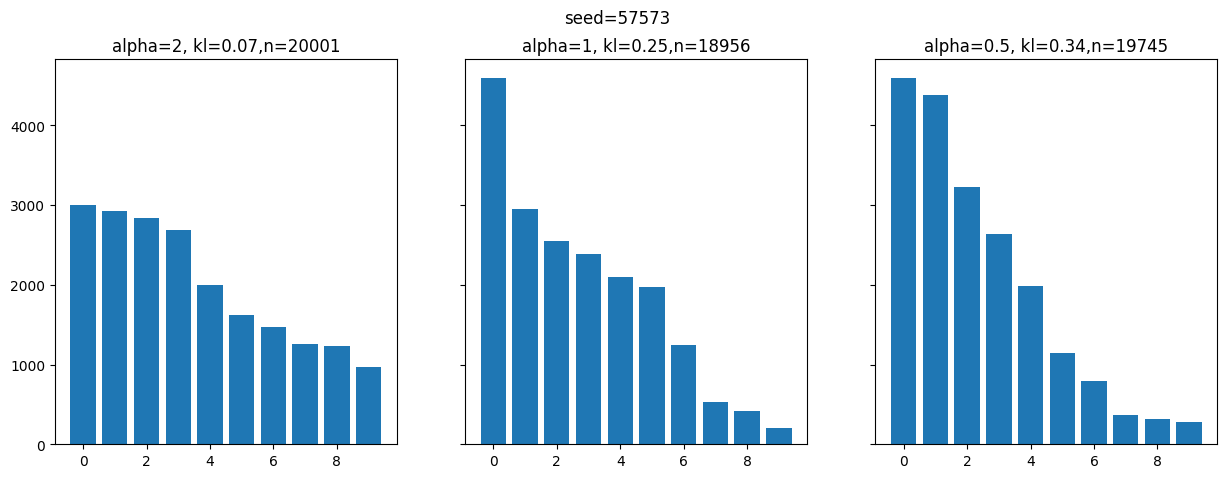

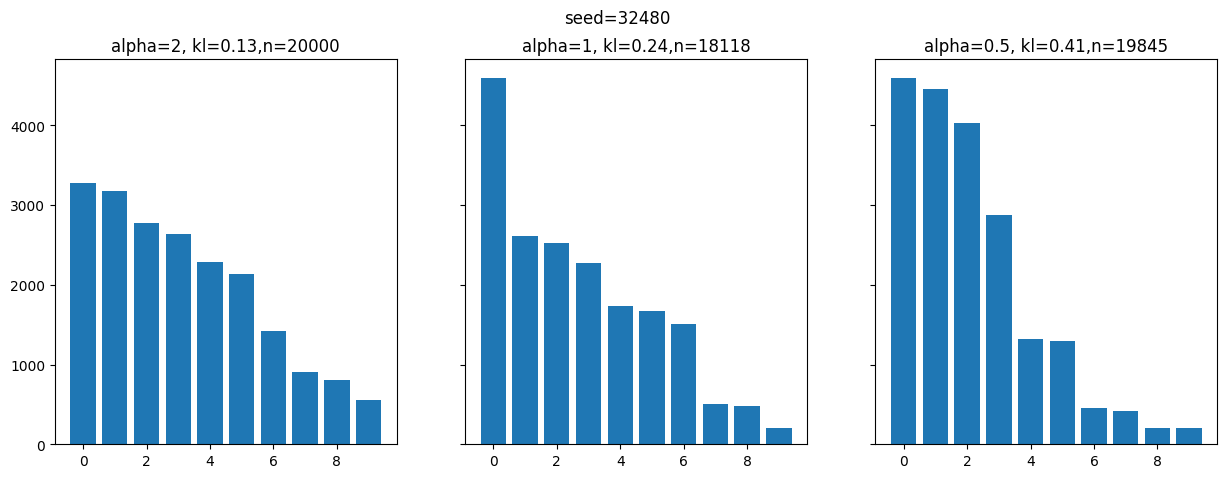

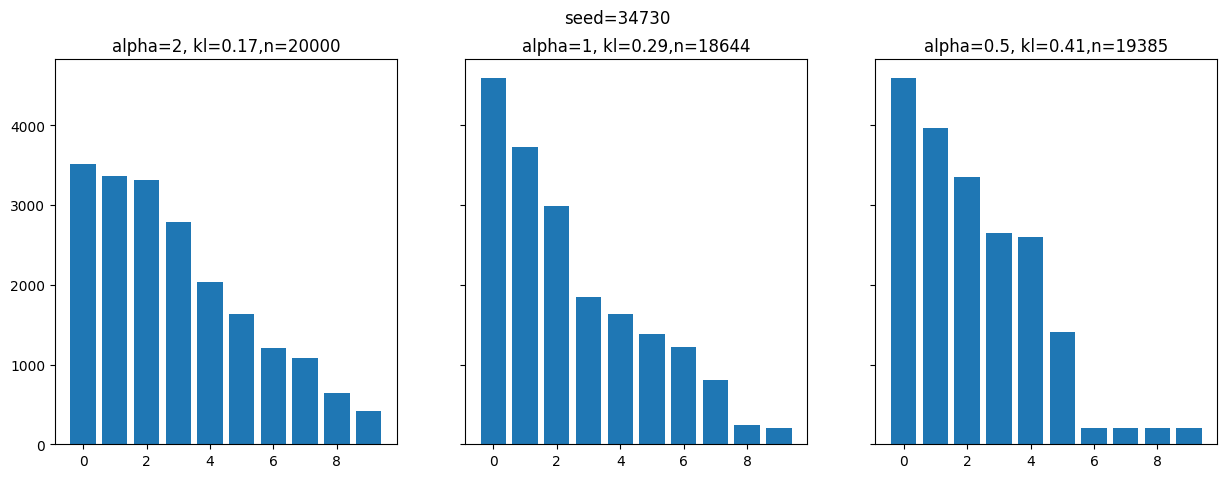

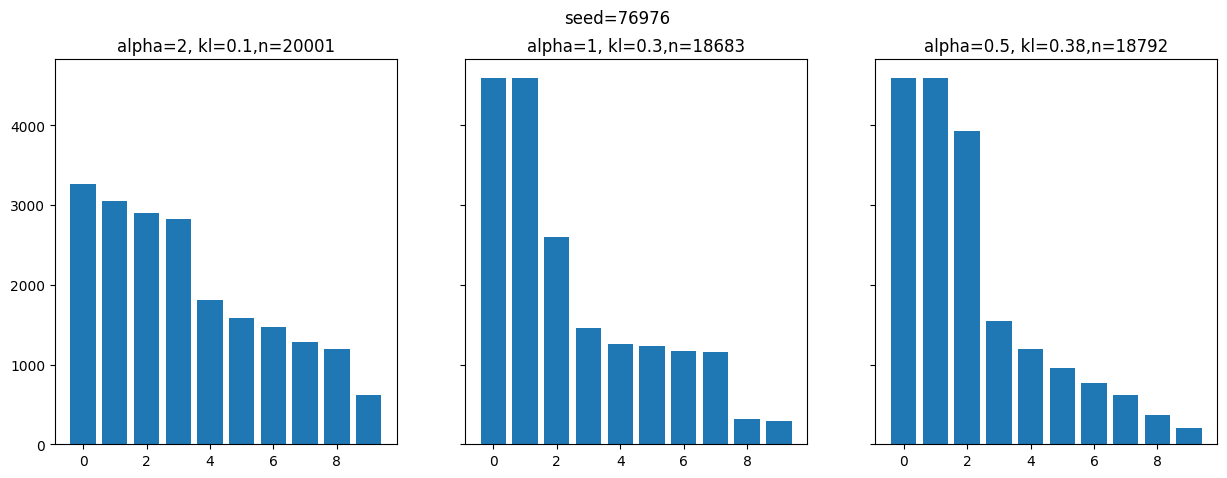

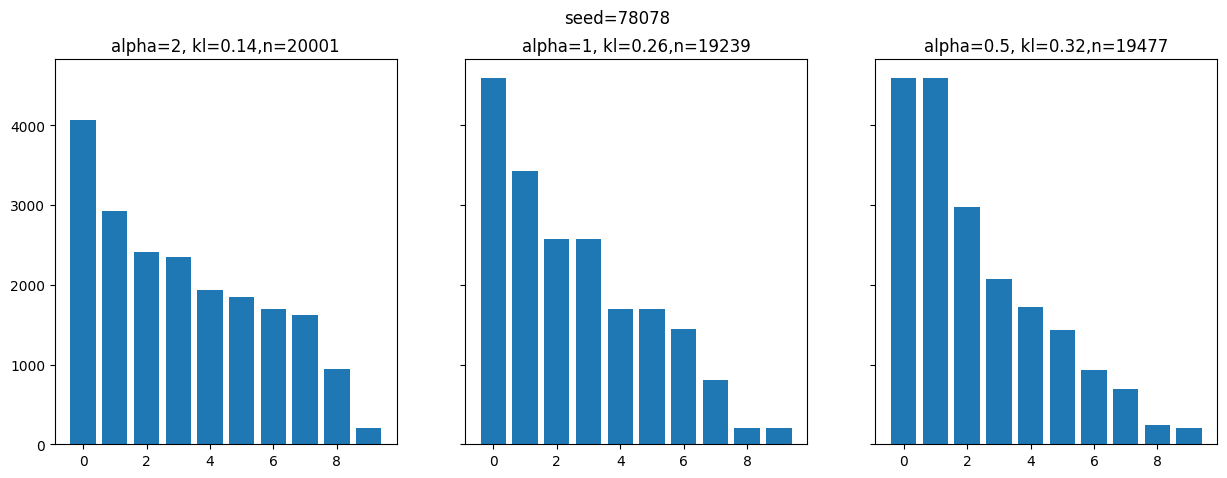

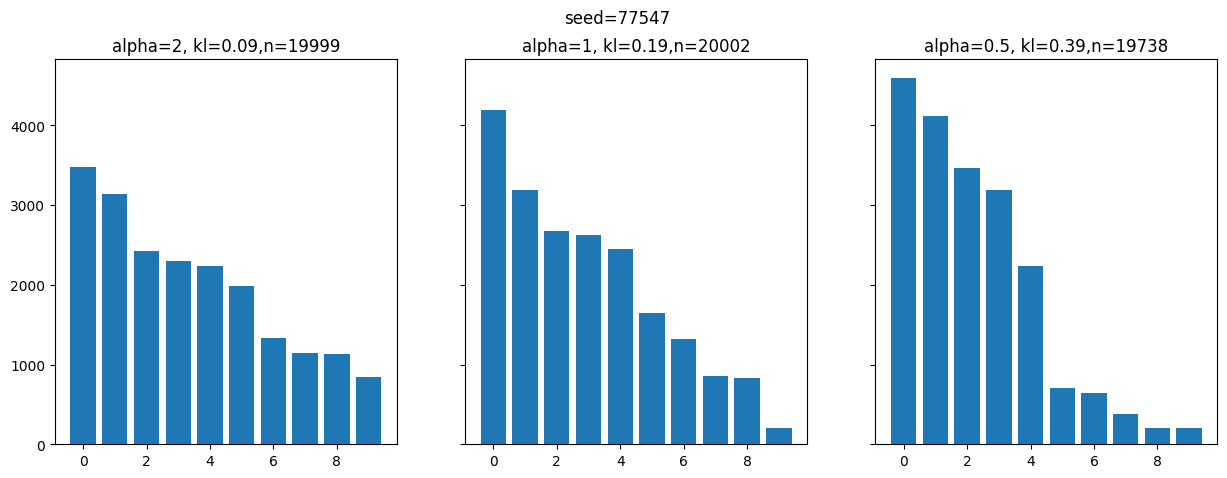

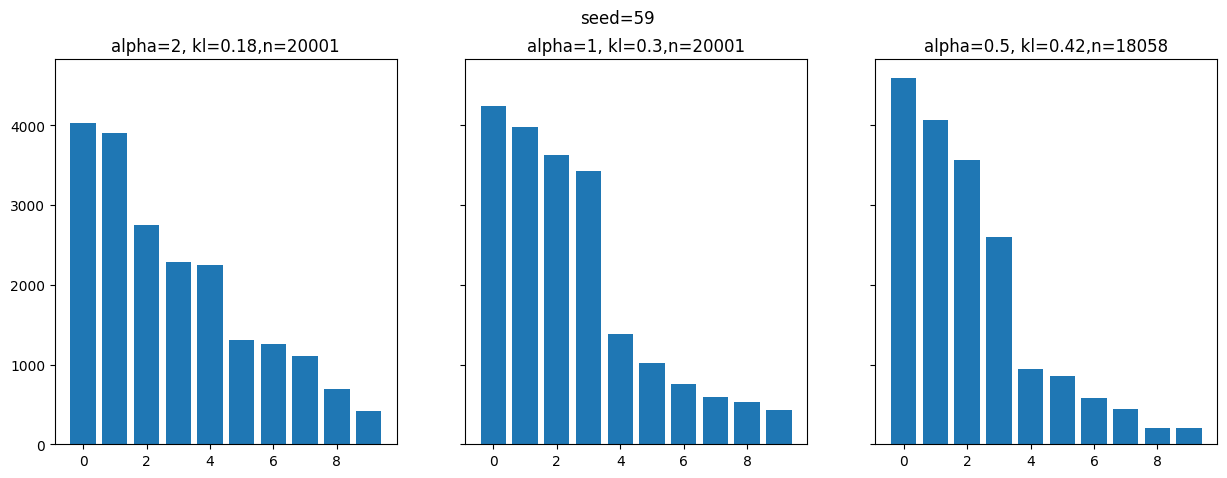

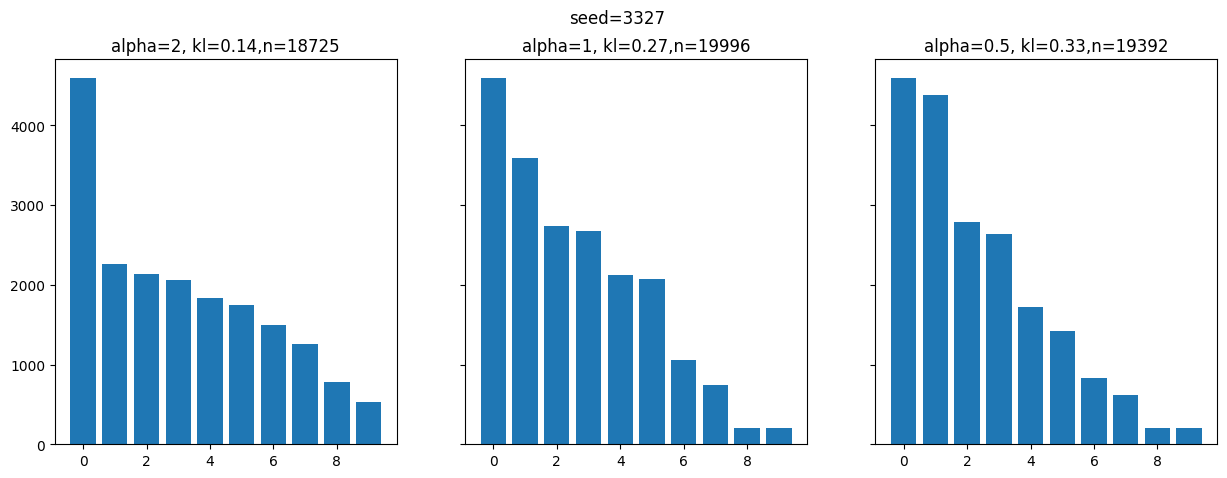

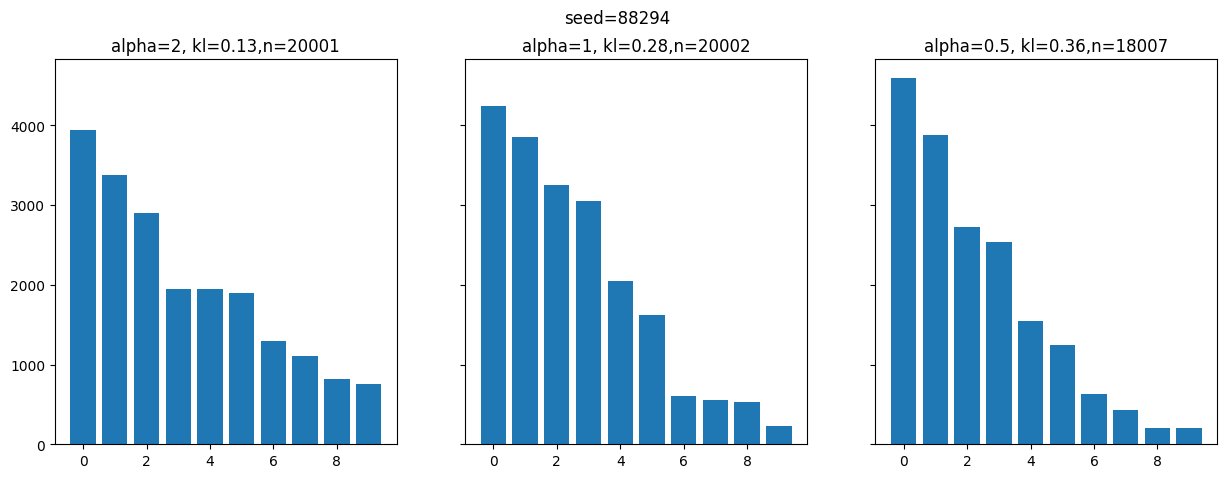

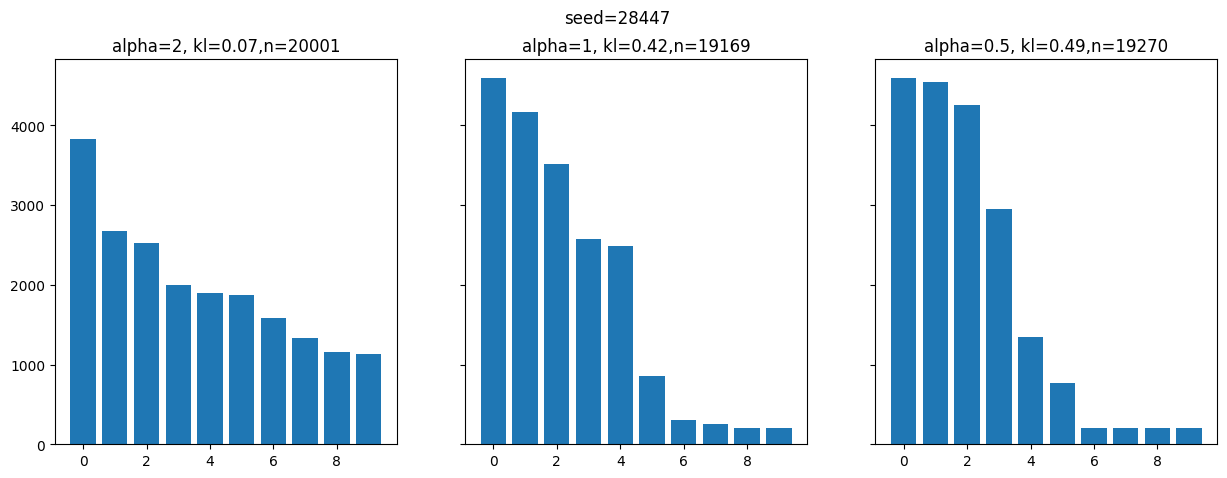

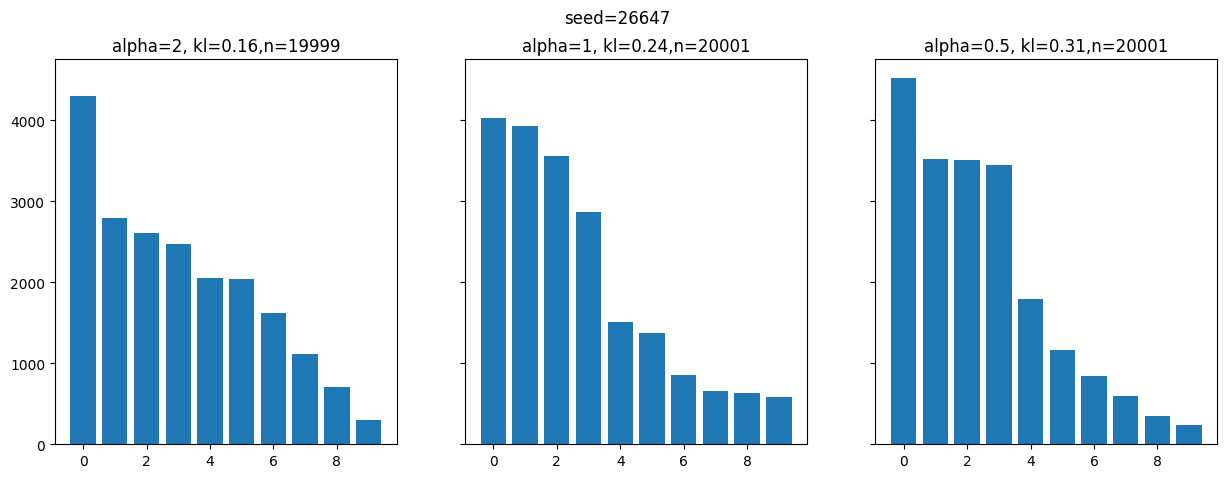

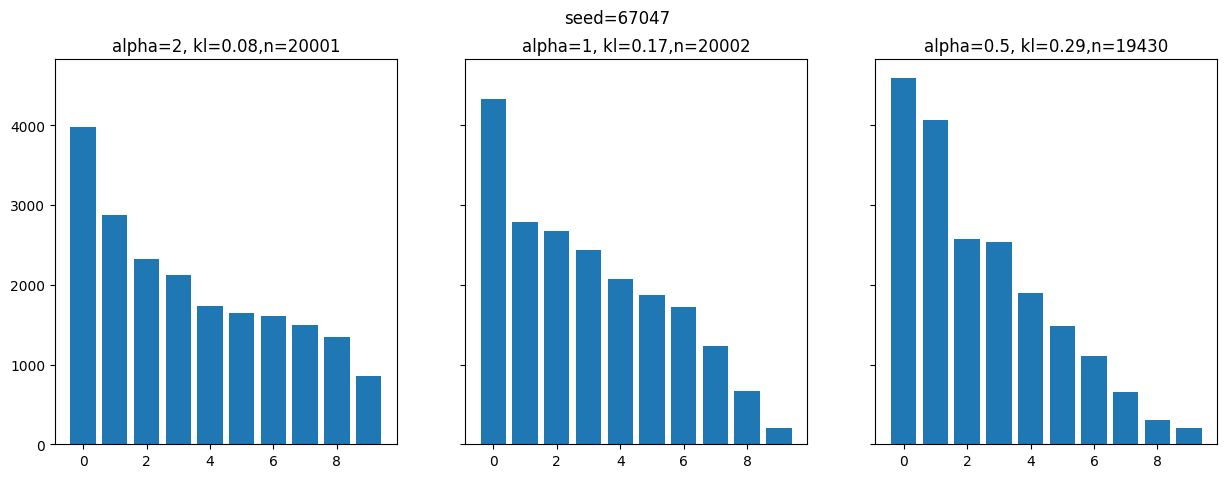

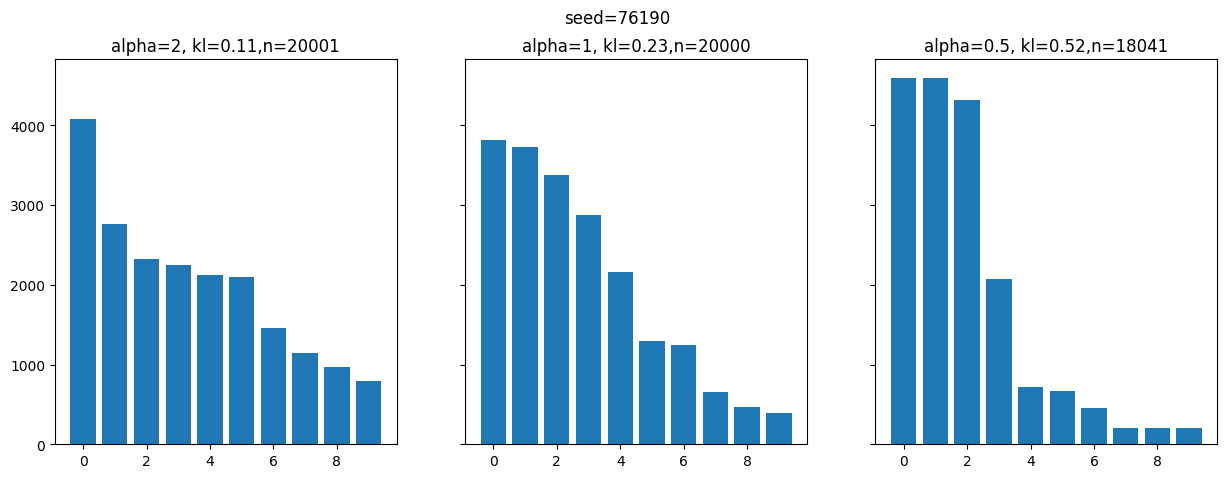

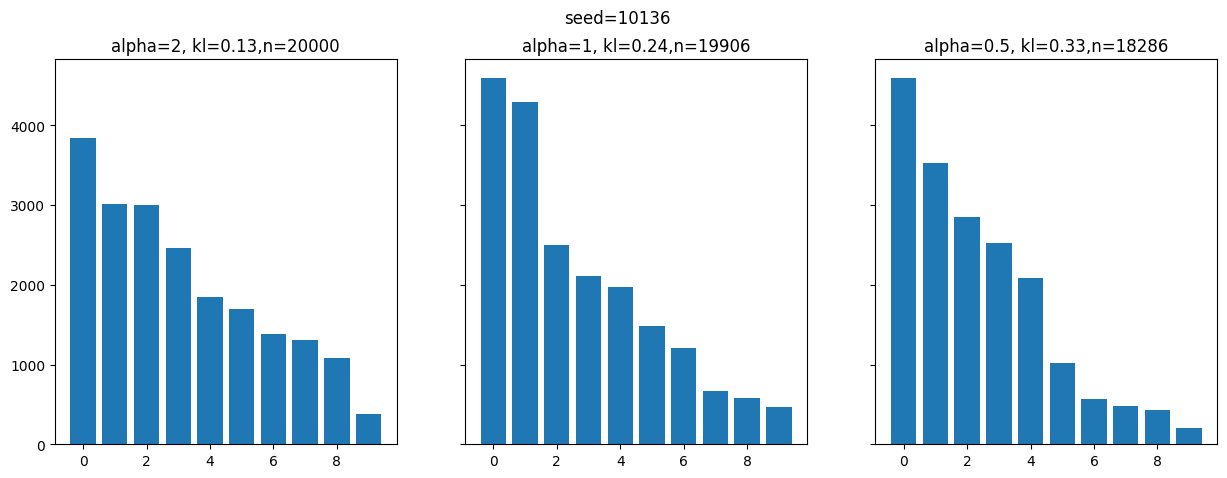

In [ ]:
alphas = [2,1,0.5]
seeds=[int(x) for x in np.random.uniform(low=1,high=100000,size=109)]
for seed in seeds:
    counts=[]
    for i in range(3):
        counts.append(preview_skew_counts(10,20000,alphas[i],200, seed,4600))
    ns=np.array([sum(counts[i])for i in range(3)])
    if np.all(ns>18000):
        targets = [np.hstack([[i]*counts[j][i]for i in range(len(counts[j]))]) for j in range(len(counts))]
        kls = [kl_from_uniform(targets[i]) for i in range(3)]
        if np.all(np.diff(kls)>0.05):
            display(f"counts: {[counts[i]for i in range(3)]}")
            fig, axes = plt.subplots(1,3,figsize=(15,5), sharey=True)

            for i in range(3):
                vis_counts(counts[i],ax=axes[i])
                axes[i].set_title(f"alpha={alphas[i]}, kl={np.round(kls[i],2)},n={len(targets[i])}")

    fig.suptitle(f"seed={seed}")

'counts: [array([4352, 3937, 3036, 2630, 2134, 1497,  771,  714,  577,  352]), array([4600, 4241, 3717, 2356, 2272, 1035,  745,  471,  200,  200]), array([4600, 4600, 3965, 2841, 1563,  891,  202,  200,  200,  200])]'

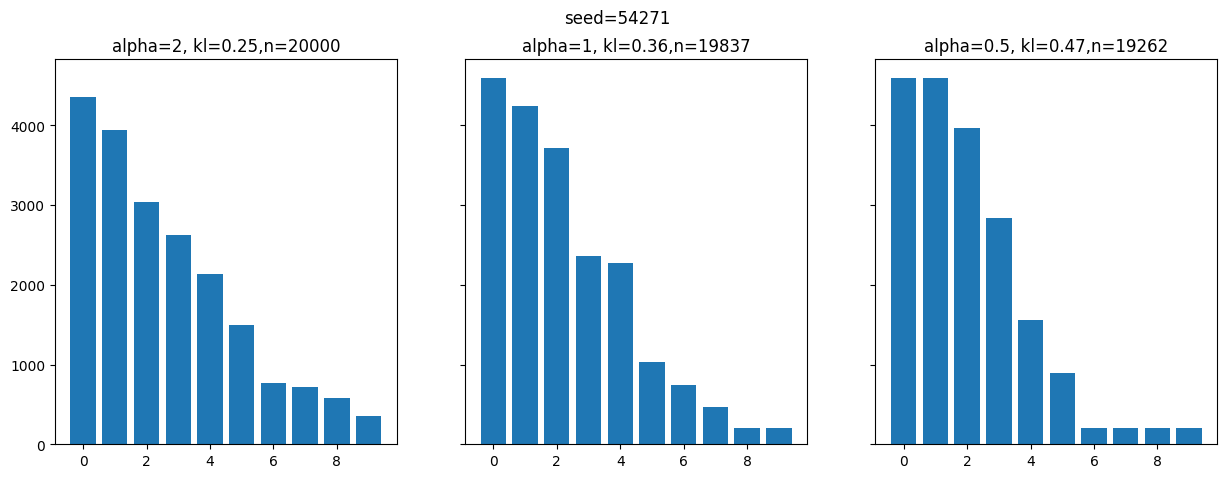

In [ ]:
alphas = [2,1,0.5]
seeds=[54271]
for seed in seeds:
    counts=[]
    for i in range(3):
        counts.append(preview_skew_counts(10,20000,alphas[i],200, seed,4600))
    ns=np.array([sum(counts[i])for i in range(3)])
    if np.all(ns>18000):
        targets = [np.hstack([[i]*counts[j][i]for i in range(len(counts[j]))]) for j in range(len(counts))]
        kls = [kl_from_uniform(targets[i]) for i in range(3)]
        if np.all(np.diff(kls)>0):
            display(f"counts: {[counts[i]for i in range(3)]}")
            fig, axes = plt.subplots(1,3,figsize=(15,5), sharey=True)

            for i in range(3):
                vis_counts(counts[i],ax=axes[i])
                axes[i].set_title(f"alpha={alphas[i]}, kl={np.round(kls[i],2)},n={len(targets[i])}")

    fig.suptitle(f"seed={seed}")
plt.show()

'counts: [array([3339, 3069, 2809, 2329, 1882, 1503, 1454, 1392, 1282,  939]), array([4600, 3420, 2579, 1990, 1437, 1370,  852,  849,  696,  537]), array([4600, 3969, 3718, 3392, 1739, 1644,  299,  200,  200,  200])]'

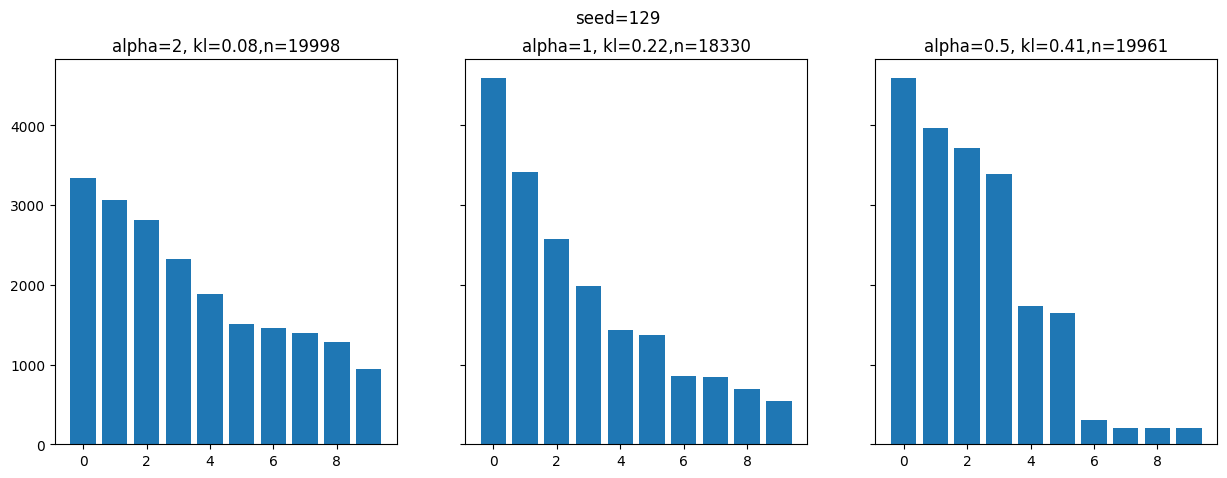

In [ ]:
alphas = [2,1,0.5]
seeds=[129]
for seed in seeds:
    counts=[]
    for i in range(3):
        counts.append(preview_skew_counts(10,20000,alphas[i],200, seed,4600))
    ns=np.array([sum(counts[i])for i in range(3)])
    if np.all(ns>18000):
        targets = [np.hstack([[i]*counts[j][i]for i in range(len(counts[j]))]) for j in range(len(counts))]
        kls = [kl_from_uniform(targets[i]) for i in range(3)]
        if np.all(np.diff(kls)>0):
            display(f"counts: {[counts[i]for i in range(3)]}")
            fig, axes = plt.subplots(1,3,figsize=(15,5), sharey=True)

            for i in range(3):
                vis_counts(counts[i],ax=axes[i])
                axes[i].set_title(f"alpha={alphas[i]}, kl={np.round(kls[i],2)},n={len(targets[i])}")

    fig.suptitle(f"seed={seed}")
plt.show()

## Best seed:129

Copied 1882 images for class airport_terminal
Copied 1392 images for class beach
Copied 2809 images for class bedroom
Copied 1503 images for class canyon
Copied 939 images for class classroom
Copied 3339 images for class forest_path
Copied 2329 images for class kitchen
Copied 3069 images for class mountain
Copied 1454 images for class office
Copied 1282 images for class restaurant

Prepared skewed dataset at C:\Users\Kacper\Documents\iad 6 sem\wb2\WB2_Project\data\places365_10_classes\129\alpha_2\train with 19998 total images.
Copied 537 images for class airport_terminal
Copied 852 images for class beach
Copied 1990 images for class bedroom
Copied 4600 images for class canyon
Copied 1437 images for class classroom
Copied 2579 images for class forest_path
Copied 849 images for class kitchen
Copied 696 images for class mountain
Copied 3420 images for class office
Copied 1370 images for class restaurant

Prepared skewed dataset at C:\Users\Kacper\Documents\iad 6 sem\wb2\WB2_Project\data\p

'counts: [19998, 18330, 19961]'

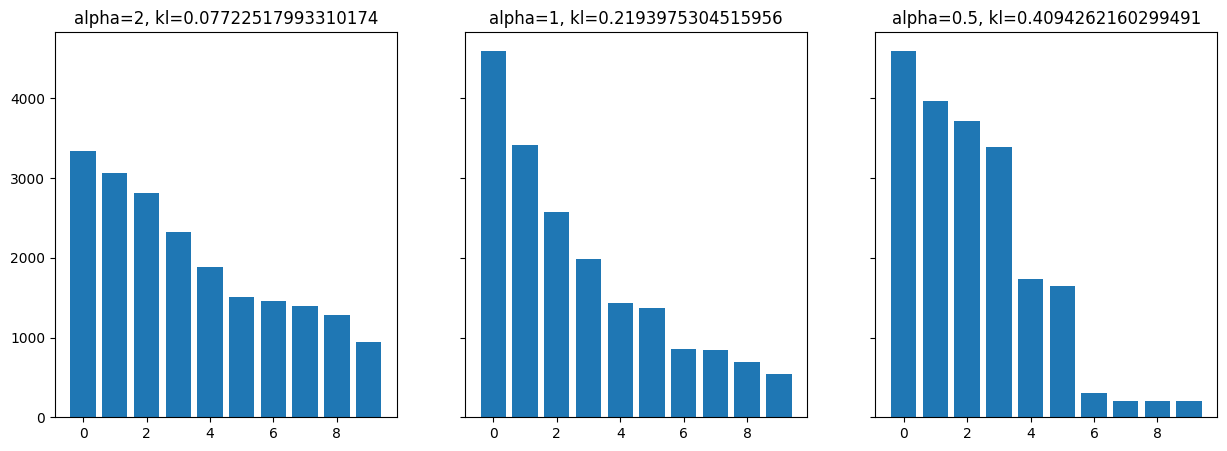

In [ ]:
from dataset_producer import prepare_skewed_train
seed=129

out_dir_base = Path(rf"C:\Users\Kacper\Documents\iad 6 sem\wb2\WB2_Project\data\places365_10_classes\{seed}")
out_dirs = [out_dir_base/"alpha_2/train",out_dir_base/"alpha_1/train",out_dir_base/"alpha_05/train"
            ]
alphas = [2,1,0.5]

for i in range(len(out_dirs)):
    prepare_skewed_train(data_dir=Path(r"C:\Users\Kacper\Documents\iad 6 sem\wb2\WB2_Project\data\places365_10_classes\split\train"),
                        out_dir=out_dirs[i],
                        target_size=20000, alpha=alphas[i], min_per_class=200, seed=seed)
    
dses = [datasets.ImageFolder(out_dirs[i]) for i in range(3)]
kls = [kl_from_uniform(np.array(dses[i].targets)) for i in range(3)]

display(f"counts: {[len(dses[i])for i in range(3)]}")
fig, axes = plt.subplots(1,3,figsize=(15,5), sharey=True)

for i in range(3):
    ds_new = dses[i]
    new_counts = list(Counter(ds_new.targets).values())
    new_counts.sort(reverse=True)
    vis_counts(new_counts,ax=axes[i])
    axes[i].set_title(f"alpha={alphas[i]}, kl={kls[i]}")


In [ ]:
base = Path(rf"C:\Users\Kacper\Documents\iad 6 sem\wb2\WB2_Project\data\places365_10_classes\{seed}")

for ending in ["alpha_1","alpha_2","alpha_05"]:
    dir_cur = base / ending
    indices_test=np.arange(len(ds_test.targets))
    dest_dir = dir_cur/"test"
    save_subset(ds_test, indices_test,dest_dir)

    indices_valid=np.arange(len(ds_valid.targets))
    dest_dir = dir_cur/"valid"
    save_subset(ds_valid, indices_valid,dest_dir)

'counts: [18330]'

Text(0.5, 0, 'Class')

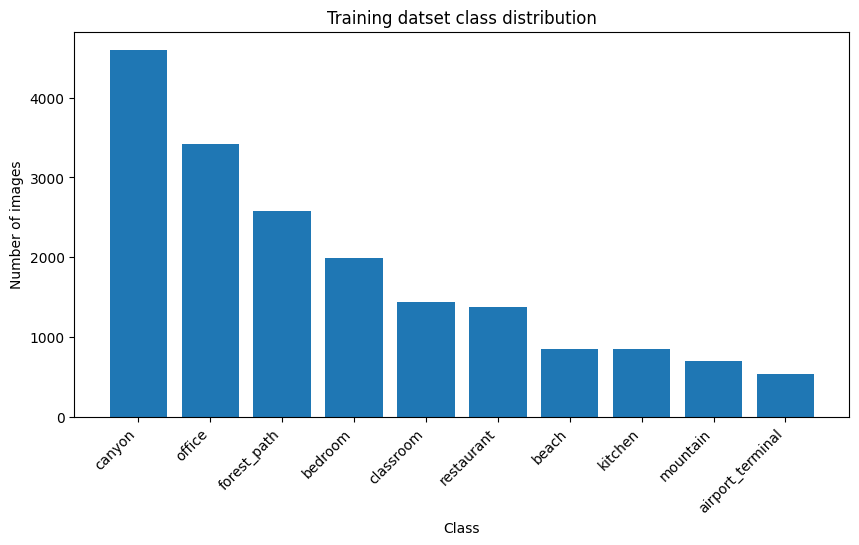

In [ ]:
def vis_counts(counts, names, ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1)
    ax.bar(x=np.arange(len(counts)), height=counts)
    ax.set_xticks(np.arange(len(counts)))
    ax.set_xticklabels(names, rotation=45, ha="right")


out_dirs = [r"C:\Users\Kacper\Documents\iad 6 sem\wb2\WB2_Project\data\places365_10_classes\129\alpha_1\train"]
dses = [datasets.ImageFolder(out_dirs[i]) for i in range(1)]
kls = [kl_from_uniform(np.array(dses[i].targets)) for i in range(1)]

display(f"counts: {[len(dses[i]) for i in range(1)]}")
fig, axes = plt.subplots(1, 1, figsize=(10, 5), sharey=True)

for i in range(1):
    ds_new = dses[i]
    class_names = ds_new.classes
    cnt = Counter(ds_new.targets)
    sorted_pairs = sorted(zip(cnt.keys(), cnt.values()), key=lambda x: x[1], reverse=True)
    sorted_names = [class_names[idx] for idx, _ in sorted_pairs]
    sorted_counts = [c for _, c in sorted_pairs]
    vis_counts(sorted_counts, sorted_names, ax=axes)

axes.set_title("Training datset class distribution")
axes.set_ylabel("Number of images")
axes.set_xlabel("Class")